# Part-fit demo: hand-picked configurations on cheap UltraScale+ parts

The manual baseline for the auto-fitter comparison. Demo A builds four
hand-chosen mark configurations of the N=64 model on `xcau7p` ($60, 37,440 LUT);
Demo B builds dual-core N=32 variants on `xcau10p`. The unmarked baseline
over-utilises or congests these parts; the marked variants fit. Produces
`part_fit_results.csv` and `part_fit_overview.png`.

**To run:** edit the config cell below — `VIVADO_SETTINGS`, checkpoint and
dataset paths. Eight place-and-route jobs at `MAX_VIVADO_PAR=3`.

In [1]:
import os
os.environ.setdefault('KERAS_BACKEND', 'jax')
os.environ.setdefault('XLA_PYTHON_CLIENT_MEM_FRACTION', '0.5')

import sys
from pathlib import Path

# ---- USER KNOBS --------------------------------------------------------------
CHECKPOINT_N64 = Path(
    '../../../models/jsc_plf/64-16/'
    'epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534.keras'
)
CHECKPOINT_N32 = Path(
    '../../../models/jsc_plf/32-16/'
    'epoch=5406-val_acc=0.805-ebops=27012-val_loss=0.570.keras'
)
FEATURES          = 16
MODEL_NAME        = 'jsc'

# Tight Vivado clock target (paper-aligned).
CLOCK_PERIOD      = 2.5             # ns -> 400 MHz target
CLOCK_UNCERTAINTY = 0.0
LATENCY_CUTOFF    = 2            # ns per stage

TRACE_BATCH       = 2048
MAX_VIVADO_PAR    = 3
VIVADO_SETTINGS   = '/tools/Xilinx/2025.1/Vivado/settings64.sh'

DSP_MAX_OPS = 1600

# ---- Demo A — single-instance N=64 on xcau7p ---------------------------------
DEMO_A_PART = 'xcau7p-sbvc484-2-e'    # Artix UltraScale+, ~$60 (sbvc484 = 484-pin)
DEMO_A_BUDGET = dict(lut=37440, ff=74880, bram_tiles=108, dsp=216, price_usd=60)

# (label, bram predicate (bw_in_thr, bw_out_thr) or None,
#  dsp-adder predicate (bo_thr, clocked) or None)
RUN_POINTS_A = [
    ('paper_baseline',                None,    None),
    ('bram_6_10__none',               (6, 10), None),
    ('bram_6_8__none',                (6, 8),  None),
    ('bram_6_8__bo15_clocked',        (6, 8),  (15, True)),
]

# ---- Demo B — dual-instance N=32 on xcau10p ----------------------------------
DEMO_B_PART = 'xcau10p-sbvb484-2-e'   # Artix UltraScale+, ~$75
DEMO_B_BUDGET = dict(lut=44000, ff=88000, bram_tiles=100, dsp=400, price_usd=75)
DEMO_B_INSTANCES = 2                   # two N=32 cores wrapped in jsc_dual

RUN_POINTS_B = [
    ('paper_baseline',                None,    None),     # 2× ⇒ fails LUT
    ('bram_6_4__none',                (6, 4),  None),     # 2× ⇒ fails BRAM
    ('bram_8_6__none',                (8, 6),  None),     # 2× ⇒ fits tight
    ('bram_8_6__bo15_clocked',        (8, 6),  (15, True)),  # 2× ⇒ fits + DSP
]

RUN_VIVADO = True
# -----------------------------------------------------------------------------

HGQ_JSC150 = Path('..').resolve()  # shared helpers: model.py, data.py, dump_bram.tcl
DATA_DIR   = Path('../../../dataset/jsc_plf').resolve()  # from prepare_datasets.sh
NB_DIR     = Path('.').resolve()
if str(HGQ_JSC150) not in sys.path:
    sys.path.insert(0, str(HGQ_JSC150))

print(f'CLOCK_PERIOD   : {CLOCK_PERIOD} ns ({1000.0/CLOCK_PERIOD:.0f} MHz target)')
print(f'LATENCY_CUTOFF : {LATENCY_CUTOFF} ns')
print()
print(f'DEMO_A part    : {DEMO_A_PART}  ({DEMO_A_BUDGET})')
print(f'DEMO_A points  : {len(RUN_POINTS_A)}')
print(f'DEMO_B part    : {DEMO_B_PART}  ({DEMO_B_BUDGET})')
print(f'DEMO_B points  : {len(RUN_POINTS_B)}  × {DEMO_B_INSTANCES} instances')
print()
print(f'Output dir     : {NB_DIR}')


CLOCK_PERIOD   : 2.5 ns (400 MHz target)
LATENCY_CUTOFF : 2 ns

DEMO_A part    : xcau7p-sbvc484-2-e  ({'lut': 37440, 'ff': 74880, 'bram_tiles': 108, 'dsp': 216, 'price_usd': 60})
DEMO_A points  : 4
DEMO_B part    : xcau10p-sbvb484-2-e  ({'lut': 44000, 'ff': 88000, 'bram_tiles': 100, 'dsp': 400, 'price_usd': 75})
DEMO_B points  : 4  × 2 instances

Output dir     : /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/masters_results_5


Probe Vivado for both parts and capture their LUT/FF/BRAM/DSP budgets.

In [2]:
import subprocess
import shlex
import re

PROBE_TCL = NB_DIR / '_probe_parts.tcl'
PROBE_TCL.write_text(f"""# auto-generated probe
foreach p {{ {DEMO_A_PART} {DEMO_B_PART} }} {{
    puts "----- $p -----"
    if {{[catch {{
        set parts [get_parts -filter "NAME == $p"]
        if {{[llength $parts] == 0}} {{ error "no parts matched" }}
        set partobj [lindex $parts 0]
        set lut "?"
        foreach prop {{LUT_OR_MEM_ELEMENTS LUT_ELEMENTS NUMBER_OF_LUTS}} {{
            if {{![catch {{set v [get_property $prop $partobj]}}]}} {{ set lut $v; break }}
        }}
        set ff "?"
        foreach prop {{FLIPFLOPS NUMBER_OF_FLIPFLOPS}} {{
            if {{![catch {{set v [get_property $prop $partobj]}}]}} {{ set ff $v; break }}
        }}
        set bram "?"
        foreach prop {{BLOCK_RAMS NUMBER_OF_BLOCK_RAMS}} {{
            if {{![catch {{set v [get_property $prop $partobj]}}]}} {{ set bram $v; break }}
        }}
        set dsp "?"
        foreach prop {{DSP DSPS NUMBER_OF_DSPS}} {{
            if {{![catch {{set v [get_property $prop $partobj]}}]}} {{ set dsp $v; break }}
        }}
        set fam [get_property FAMILY $partobj]
        puts "PROBE_OK $p fam=$fam LUT=$lut FF=$ff BRAM=$bram DSP=$dsp"
    }} err]}} {{
        puts "PROBE_FAIL $p :: $err"
    }}
}}
exit 0
""")

cmd = f'set -e\nsource {shlex.quote(VIVADO_SETTINGS)}\nvivado -mode batch -source {shlex.quote(str(PROBE_TCL))} -nojournal -nolog'
res = subprocess.run(['bash', '-lc', cmd], capture_output=True, text=True, cwd=str(NB_DIR))
print(res.stdout[-4000:])
if res.returncode != 0:
    print('=== STDERR ===')
    print(res.stderr[-2000:])

# Parse PROBE_OK lines
probe_budgets = {}
for line in res.stdout.splitlines():
    m = re.match(r'PROBE_OK (\S+) fam=(\S+) LUT=(\S+) FF=(\S+) BRAM=(\S+) DSP=(\S+)', line)
    if m:
        p, fam, lut, ff, bram, dsp = m.groups()
        probe_budgets[p] = dict(family=fam, lut=int(lut), ff=int(ff),
                                bram_tiles=int(bram), dsp=int(dsp))
    if line.startswith('PROBE_FAIL'):
        raise RuntimeError(line)

print()
print('Vivado-reported budgets vs hardcoded:')
for p, hard in [(DEMO_A_PART, DEMO_A_BUDGET), (DEMO_B_PART, DEMO_B_BUDGET)]:
    rep = probe_budgets.get(p)
    if rep is None:
        raise RuntimeError(f'{p} did not appear in PROBE_OK output')
    print(f'  {p}')
    for k in ('lut', 'ff', 'bram_tiles', 'dsp'):
        match = '✓' if rep[k] == hard[k] else f'≠ HARD={hard[k]}'
        print(f'    {k:<12s}: Vivado={rep[k]:>7d}  {match}')


pyenv: cannot rehash: /usr/share/pyenv/shims isn't writable

****** Vivado v2025.1 (64-bit)
  **** SW Build 6140274 on Wed May 21 22:58:25 MDT 2025
  **** IP Build 6138677 on Thu May 22 03:10:11 MDT 2025
  **** SharedData Build 6139179 on Tue May 20 17:58:58 MDT 2025
  **** Start of session at: Mon May 25 22:54:52 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.

source /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/masters_results_5/_probe_parts.tcl
# foreach p { xcau7p-sbvc484-2-e xcau10p-sbvb484-2-e } {
#     puts "----- $p -----"
#     if {[catch {
#         set parts [get_parts -filter "NAME == $p"]
#         if {[llength $parts] == 0} { error "no parts matched" }
#         set partobj [lindex $parts 0]
#         set lut "?"
#         foreach prop {LUT_OR_MEM_ELEMENTS LUT_ELEMENTS NUMBER_OF_LUTS} {
#             if {![catch {set v [get_property $prop $partobj]}]} { set lut $v; break }
#   

Load the two cached pre-traced checkpoints.

In [3]:
import keras
from model import SameDim0
from data import get_data
from hgq.utils import trace_minmax


def _load_traced(raw_ckpt: Path, n_particles: int):
    raw_ckpt = raw_ckpt.expanduser().resolve()
    traced = raw_ckpt.parent / f'model_traced_n{n_particles}_f{FEATURES}.keras'
    if not traced.exists():
        print(f'No cache for N={n_particles}; running trace_minmax...')
        raw = keras.models.load_model(raw_ckpt, compile=False,
                                      custom_objects={'SameDim0': SameDim0})
        (X_train, _), (X_val, _), _ = get_data(DATA_DIR, n_particles, FEATURES == 3)
        trace_minmax(raw, X_train, batch_size=TRACE_BATCH, reset=True,  verbose=True)
        trace_minmax(raw, X_val,   batch_size=TRACE_BATCH, reset=False, verbose=True)
        raw.save(traced)
    m = keras.models.load_model(traced, compile=False,
                                custom_objects={'SameDim0': SameDim0})
    assert m.input_shape[1] == n_particles
    return m, raw_ckpt.stem

model_n64, stem_n64 = _load_traced(CHECKPOINT_N64, 64)
model_n32, stem_n32 = _load_traced(CHECKPOINT_N32, 32)
print(f'Loaded N=64: input={model_n64.input_shape}, layers={[l.__class__.__name__ for l in model_n64.layers][:6]} ...')
print(f'Loaded N=32: input={model_n32.input_shape}, layers={[l.__class__.__name__ for l in model_n32.layers][:6]} ...')


Loaded N=64: input=(None, 64, 16), layers=['InputLayer', 'QDenseT', 'QSum', 'QDenseT', 'QDenseT', 'QAdd'] ...
Loaded N=32: input=(None, 32, 16), layers=['InputLayer', 'QDenseT', 'QSum', 'QDenseT', 'QDenseT', 'QAdd'] ...


Helpers: trace, apply mark passes, write the RTL project.

In [4]:
import shutil
import numpy as np
from da4ml.cmvm import dsp_offload
from da4ml.converter import trace_model
from da4ml.trace import HWConfig, comb_trace, mark_bram, mark_dsp, mark_dsp_adder
from da4ml.codegen import RTLModel

HW_CONFIG      = HWConfig(1, -1, -1)
DSP_OFFLOAD_FN = dsp_offload(min_csd_terms=2, min_var_bits=4, max_const_bits=18, max_ops=None)
SOLVER_OPTIONS = {'hard_dc': 2, 'dsp_offload_fn': DSP_OFFLOAD_FN}


def trace_base(model):
    inp, out = trace_model(model, hwconf=HW_CONFIG, solver_options=SOLVER_OPTIONS, verbose=False)
    return comb_trace(inp, out)


def apply_marks(comb, bram, dsp_adder):
    if bram is not None:
        bi, bo = bram
        comb = mark_bram(
            comb,
            predicate=lambda bw_in, bw_out, bi=bi, bo=bo: bw_in >= bi and bw_out >= bo,
            latency_cutoff=LATENCY_CUTOFF,
        )
    comb = mark_dsp(comb, predicate=lambda *_: True, latency_cutoff=LATENCY_CUTOFF)
    if dsp_adder is not None:
        bo_th, clocked = dsp_adder
        comb = mark_dsp_adder(
            comb,
            predicate=lambda b0, b1, bo_, _bo=bo_th: bo_ >= _bo,
            latency_cutoff=LATENCY_CUTOFF,
            clocked=clocked,
            max_ops=DSP_MAX_OPS,
            max_iter=1024,
        )
    return comb


def _count_marks(comb):
    n_bram = sum(1 for op in comb.ops if op.opcode == 8 and (op.data >> 32) & 1)
    n_clk  = sum(1 for op in comb.ops if op.opcode in (0, 1, 4) and (op.impl & 1))
    n_cmb  = sum(1 for op in comb.ops if op.opcode in (0, 1, 4) and (op.impl & 2))
    return n_bram, n_clk, n_cmb


def make_run_project(model, model_stem, label, bram, dsp_adder, *, part_name, demo_dir):
    """Apply marks + write RTL for one (label) under `demo_dir/label/model_stem`."""
    comb = apply_marks(trace_base(model), bram, dsp_adder)
    n_bram, n_clk, n_cmb = _count_marks(comb)
    lat = max(op.latency for op in comb.ops)
    n_stages = int(np.ceil(lat / LATENCY_CUTOFF))

    grid_dir = demo_dir / label
    out_path = grid_dir / model_stem
    if grid_dir.exists():
        shutil.rmtree(grid_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    rtl = RTLModel(
        comb, MODEL_NAME, str(out_path),
        latency_cutoff=LATENCY_CUTOFF,
        clock_period=CLOCK_PERIOD,
        part_name=part_name,
        clock_uncertainty=CLOCK_UNCERTAINTY,
    )
    rtl.write()

    return dict(
        label=label, bram=bram, dsp_adder=dsp_adder,
        part_name=part_name,
        n_bram_promoted=n_bram,
        n_dsp_add_clocked=n_clk,
        n_dsp_add_comb=n_cmb,
        ir_stages=n_stages,
        ir_latency_ns=float(lat),
        prj_dir=out_path,
    )

print('Helpers ready.')


Helpers ready.


Demo A: four configurations of N=64 on `xcau7p`.

In [5]:
DEMO_A_DIR = NB_DIR / 'demoA_n64_xcau7p_2_5'
DEMO_A_DIR.mkdir(exist_ok=True)

records_A = []
for label, bram, dsp_adder in RUN_POINTS_A:
    print('=' * 78)
    print(label)
    r = make_run_project(model_n64, stem_n64, label, bram, dsp_adder,
                         part_name=DEMO_A_PART, demo_dir=DEMO_A_DIR)
    r['demo'] = 'A'
    r['n_instances'] = 1
    r['model_n'] = 64
    print(f'  Promotions  : bram={r["n_bram_promoted"]}  dsp_clk={r["n_dsp_add_clocked"]}  dsp_cmb={r["n_dsp_add_comb"]}')
    print(f'  IR latency  : {r["ir_latency_ns"]:.1f} ns ({r["ir_stages"]} stages @ {LATENCY_CUTOFF} ns)')
    records_A.append(r)

print(f'\nWrote {len(records_A)} Demo-A project(s).')


paper_baseline
  Promotions  : bram=0  dsp_clk=0  dsp_cmb=0
  IR latency  : 33.0 ns (17 stages @ 2 ns)
bram_6_10__none
  Promotions  : bram=34  dsp_clk=0  dsp_cmb=0
  IR latency  : 52.0 ns (26 stages @ 2 ns)
bram_6_8__none
  Promotions  : bram=130  dsp_clk=0  dsp_cmb=0
  IR latency  : 58.0 ns (29 stages @ 2 ns)
bram_6_8__bo15_clocked
  Promotions  : bram=130  dsp_clk=196  dsp_cmb=0
  IR latency  : 86.0 ns (43 stages @ 2 ns)

Wrote 4 Demo-A project(s).


Demo B: dual-core N=32 on `xcau10p` (a `jsc_dual` wrapper becomes the synthesis top).

In [6]:
import re

_PORT_RE = re.compile(
    r"input\s*\[(\d+):0\]\s*model_inp\s*,\s*"
    r"output(?:\s+reg)?\s*\[(\d+):0\]\s*model_out",
    re.S,
)


def _extract_widths(jsc_v_path: Path):
    text = jsc_v_path.read_text()
    m = _PORT_RE.search(text)
    if not m:
        raise RuntimeError(f'Could not extract widths from {jsc_v_path}')
    return int(m.group(1)), int(m.group(2))  # (msb_inp, msb_out) where width = msb+1


def _emit_dual_top(jsc_v_path: Path, n_instances: int) -> str:
    inp_msb, out_msb = _extract_widths(jsc_v_path)
    inp_w = inp_msb + 1
    out_w = out_msb + 1

    inst_lines = []
    port_inputs = []
    port_outputs = []
    for i in range(n_instances):
        inst_lines.append(
            f'    jsc u{i} (.clk(clk), .model_inp(model_inp_{i}), .model_out(model_out_{i}));'
        )
        port_inputs.append(f'    input  [{inp_msb}:0] model_inp_{i},')
        port_outputs.append(f'    output [{out_msb}:0] model_out_{i}{"," if i < n_instances - 1 else ""}')

    return (
        '`timescale 1 ns / 1 ps\n\n'
        '// Auto-generated by part_fit_demonstration.ipynb (Demo B).\n'
        f'// Wraps {n_instances} instance(s) of `jsc` (width={inp_w}b in, {out_w}b out).\n\n'
        'module jsc_dual (\n'
        '    input clk,\n'
        + '\n'.join(port_inputs) + '\n'
        + '\n'.join(port_outputs) + '\n'
        ');\n\n'
        + '\n'.join(inst_lines) + '\n\n'
        'endmodule\n'
    )


def _patch_build_tcl(tcl_path: Path, new_top: str):
    text = tcl_path.read_text()
    new_text = re.sub(
        r'set top_module \"\${project_name}\"',
        f'set top_module "{new_top}"',
        text,
        count=1,
    )
    if new_text == text:
        raise RuntimeError(f'Failed to patch top_module in {tcl_path}')
    tcl_path.write_text(new_text)


def make_dual_instance(record, n_instances: int):
    """Add jsc_dual.v + patch build TCL inside an already-written single-instance project."""
    prj_dir = record['prj_dir']
    src_dir = prj_dir / 'src'
    jsc_v   = src_dir / 'jsc.v'
    dual_v  = src_dir / 'jsc_dual.v'

    dual_v.write_text(_emit_dual_top(jsc_v, n_instances))
    _patch_build_tcl(prj_dir / 'build_vivado_prj.tcl', new_top='jsc_dual')

    inp_msb, out_msb = _extract_widths(jsc_v)
    record['dual_inp_w'] = inp_msb + 1
    record['dual_out_w'] = out_msb + 1
    record['n_instances'] = n_instances
    return record

print('Demo-B helpers ready.')


Demo-B helpers ready.


In [7]:
DEMO_B_DIR = NB_DIR / 'demoB_n32x2_xcau10p_2_5'
DEMO_B_DIR.mkdir(exist_ok=True)

records_B = []
for label, bram, dsp_adder in RUN_POINTS_B:
    print('=' * 78)
    print(label, f' (× {DEMO_B_INSTANCES})')
    r = make_run_project(model_n32, stem_n32, label, bram, dsp_adder,
                         part_name=DEMO_B_PART, demo_dir=DEMO_B_DIR)
    r['demo'] = 'B'
    r['model_n'] = 32
    r = make_dual_instance(r, n_instances=DEMO_B_INSTANCES)
    print(f'  Promotions  : bram={r["n_bram_promoted"]}  dsp_clk={r["n_dsp_add_clocked"]}  dsp_cmb={r["n_dsp_add_comb"]}')
    print(f'  IR latency  : {r["ir_latency_ns"]:.1f} ns ({r["ir_stages"]} stages)')
    print(f'  Dual top    : jsc_dual.v written with {r["n_instances"]} instances ({r["dual_inp_w"]}b in, {r["dual_out_w"]}b out)')
    records_B.append(r)

print(f'\nWrote {len(records_B)} Demo-B project(s) (each = {DEMO_B_INSTANCES} jsc instances).')


paper_baseline  (× 2)
  Promotions  : bram=0  dsp_clk=0  dsp_cmb=0
  IR latency  : 30.0 ns (15 stages)
  Dual top    : jsc_dual.v written with 2 instances (2330b in, 54b out)
bram_6_4__none  (× 2)
  Promotions  : bram=539  dsp_clk=0  dsp_cmb=0
  IR latency  : 58.0 ns (29 stages)
  Dual top    : jsc_dual.v written with 2 instances (2330b in, 54b out)
bram_8_6__none  (× 2)
  Promotions  : bram=110  dsp_clk=0  dsp_cmb=0
  IR latency  : 54.0 ns (27 stages)
  Dual top    : jsc_dual.v written with 2 instances (2330b in, 54b out)
bram_8_6__bo15_clocked  (× 2)
  Promotions  : bram=110  dsp_clk=56  dsp_cmb=0
  IR latency  : 74.0 ns (37 stages)
  Dual top    : jsc_dual.v written with 2 instances (2330b in, 54b out)

Wrote 4 Demo-B project(s) (each = 2 jsc instances).


Guard: stage file count vs IR latency.

In [8]:
import json
import re as _re

pat_stage = _re.compile(r'jsc_stage(\d+)\.v$')
mismatches = []
for r in records_A + records_B:
    src = r['prj_dir'] / 'src'
    meta = json.loads((r['prj_dir'] / 'metadata.json').read_text())
    n_v = sum(1 for vf in src.glob('jsc_stage*.v') if pat_stage.search(vf.name))
    if n_v != meta['latency']:
        mismatches.append((r['demo'], r['label'], n_v, meta['latency']))

if mismatches:
    for demo, label, n_v, lat in mismatches:
        print(f'!! Demo {demo}: {label}: stage_files={n_v} != meta.latency={lat}')
    raise AssertionError('Stage-count mismatch — likely stale .v files.')
print(f'All {len(records_A) + len(records_B)} projects consistent (stage_files == metadata.latency).')


All 8 projects consistent (stage_files == metadata.latency).


Run Vivado on all 8 projects; placement failure on over-utilisation is an expected outcome for the baseline.

In [9]:
import shlex
import subprocess
import time
from collections import deque

def start_vivado_job(tcl_path):
    run_dir = tcl_path.parent
    out_f = open(run_dir / 'vivado_stdout.log', 'w')
    err_f = open(run_dir / 'vivado_stderr.log', 'w')
    bash_cmd = (
        f'set -e\n'
        f'source {shlex.quote(VIVADO_SETTINGS)}\n'
        f'vivado -mode batch -source {shlex.quote(str(tcl_path.resolve()))} -nojournal -nolog\n'
    )
    proc = subprocess.Popen(['bash', '-lc', bash_cmd], cwd=str(run_dir),
                            stdout=out_f, stderr=err_f, text=True)
    return dict(tcl_path=tcl_path, run_dir=run_dir, proc=proc,
                out_f=out_f, err_f=err_f, start=time.time())

if RUN_VIVADO:
    all_records = records_A + records_B
    tcl_paths = [r['prj_dir'] / 'build_vivado_prj.tcl' for r in all_records]

    queue = deque(zip(tcl_paths, all_records))
    running, done = [], []

    def drain():
        while queue and len(running) < MAX_VIVADO_PAR:
            tcl, rec = queue.popleft()
            j = start_vivado_job(tcl)
            j['record'] = rec
            running.append(j)
            print(f'[START]  demo{rec["demo"]} {rec["label"]:<28s}  pid={j["proc"].pid}')

    drain()
    while running:
        time.sleep(1.0)
        for j in list(running):
            rc = j['proc'].poll()
            if rc is None:
                continue
            j['out_f'].close(); j['err_f'].close()
            dt = time.time() - j['start']
            rec = j['record']
            tag = f'demo{rec["demo"]} {rec["label"]}'
            print(f'[{("OK" if rc == 0 else f"FAIL(rc={rc})"):<11s}] {tag:<35s}  t={dt:.1f}s')
            done.append(dict(rec=rec, rc=rc, elapsed=dt))
            running.remove(j); drain()

    failed = [d for d in done if d['rc'] != 0]
    print(f'\nVivado done {len(done)}/{len(tcl_paths)}; nonzero rc: {len(failed)} (those are candidates for util_fail; see next cell)')
else:
    print('RUN_VIVADO=False — skipping.')


[START]  demoA paper_baseline                pid=1093169
[START]  demoA bram_6_10__none               pid=1093170
[START]  demoA bram_6_8__none                pid=1093172
[FAIL(rc=1) ] demoA paper_baseline                 t=294.0s
[START]  demoA bram_6_8__bo15_clocked        pid=1280116
[FAIL(rc=1) ] demoA bram_6_10__none                t=326.0s
[START]  demoB paper_baseline                pid=1284357
[OK         ] demoA bram_6_8__none                 t=566.1s
[START]  demoB bram_6_4__none                pid=1342479
[FAIL(rc=1) ] demoB paper_baseline                 t=311.0s
[START]  demoB bram_8_6__none                pid=1376900
[FAIL(rc=1) ] demoB bram_6_4__none                 t=202.0s
[START]  demoB bram_8_6__bo15_clocked        pid=1384547
[OK         ] demoA bram_6_8__bo15_clocked         t=598.1s
[OK         ] demoB bram_8_6__none                 t=415.0s
[OK         ] demoB bram_8_6__bo15_clocked         t=405.0s

Vivado done 8/8; nonzero rc: 4 (those are candidates for util_f

Parse reports and classify each run (fits / fails; post-place and post-route WNS).

In [10]:
import json
import re as _re
import numpy as np
import pandas as pd

def _util_used(text, label):
    m = _re.search(
        r'^\|\s*' + _re.escape(label) + r'\s*\|\s*([\d.]+)\s*\|',
        text, _re.MULTILINE,
    )
    return float(m.group(1)) if m else float('nan')

def _util_avail(text, label):
    # |   ...   | Used | Fixed | Prohibited | Available | Util% |
    m = _re.search(
        r'^\|\s*' + _re.escape(label) +
        r'\s*\|\s*[\d.]+\s*\|[^|]+\|[^|]+\|\s*([\d.]+)\s*\|',
        text, _re.MULTILINE,
    )
    return float(m.group(1)) if m else float('nan')

def _parse_timing(text):
    """Return (wns_ns, achieved_ns, fmax_mhz). NaN if no match."""
    m = _re.search(r'WNS\(ns\)[^\n]*\n[^\n]*\n\s*([-\d.]+)', text)
    wns = float(m.group(1)) if m else float('nan')
    achieved = CLOCK_PERIOD - wns if not np.isnan(wns) else float('nan')
    fmax = 1000.0 / achieved if achieved and achieved > 0 else float('nan')
    return wns, achieved, fmax

LABELS = ('CLB LUTs', 'CLB Registers', 'Block RAM Tile', 'DSPs')

rows = []
for r in records_A + records_B:
    reports_dir = r['prj_dir'] / 'output_jsc' / 'reports'
    post_route_util = reports_dir / 'jsc_post_route_util.rpt'
    post_route_tim  = reports_dir / 'jsc_post_route_timing.rpt'
    post_place_tim  = reports_dir / 'jsc_post_place_timing.rpt'
    post_synth_util = reports_dir / 'jsc_post_synth_util.rpt'

    used = {k: float('nan') for k in ('lut','ff','bram_tiles','dsp')}
    avail = {k: float('nan') for k in ('lut','ff','bram_tiles','dsp')}
    pp_wns = pp_fmax = pp_achieved = float('nan')
    pr_wns = pr_fmax = pr_achieved = float('nan')
    rep_source = None

    if post_route_util.exists():
        text = post_route_util.read_text()
        rep_source = 'post_route'
    elif post_synth_util.exists():
        text = post_synth_util.read_text()
        rep_source = 'post_synth'
    else:
        text = None
        rep_source = 'missing'

    if text is not None:
        used['lut']         = _util_used(text, 'CLB LUTs')
        used['ff']          = _util_used(text, 'CLB Registers')
        used['bram_tiles']  = _util_used(text, 'Block RAM Tile')
        used['dsp']         = _util_used(text, 'DSPs')
        avail['lut']        = _util_avail(text, 'CLB LUTs')
        avail['ff']         = _util_avail(text, 'CLB Registers')
        avail['bram_tiles'] = _util_avail(text, 'Block RAM Tile')
        avail['dsp']        = _util_avail(text, 'DSPs')

    if post_place_tim.exists():
        pp_wns, pp_achieved, pp_fmax = _parse_timing(post_place_tim.read_text())
    if post_route_tim.exists():
        pr_wns, pr_achieved, pr_fmax = _parse_timing(post_route_tim.read_text())

    # Primary WNS = post-place (logic-delay-only).
    wns = pp_wns
    achieved = pp_achieved
    fmax = pp_fmax

    # Classify
    if rep_source == 'missing':
        status = 'build_fail'
    else:
        over = []
        for k in ('lut','ff','bram_tiles','dsp'):
            u, a = used[k], avail[k]
            if not (np.isnan(u) or np.isnan(a)) and u > a:
                over.append(k)
        if over:
            status = 'util_fail (' + ','.join(over) + ')'
        elif rep_source == 'post_synth':
            status = 'build_fail (post-synth only)'
        elif np.isnan(pp_wns):
            status = 'build_fail (no timing rpt)'
        elif pp_wns < 0:
            status = 'timing_fail'
        elif not np.isnan(pr_wns) and pr_wns < 0:
            status = 'fits (routing-congested)'
        else:
            status = 'fits'

    meta_path = r['prj_dir'] / 'metadata.json'
    meta = json.loads(meta_path.read_text()) if meta_path.exists() else {}
    cycles = meta.get('latency', float('nan'))
    rows.append({
        'demo': r['demo'],
        'label': r['label'],
        'model_n': r['model_n'],
        'n_instances': r['n_instances'],
        'part': r['part_name'],
        'bram_pred': str(r['bram']) if r['bram'] else '-',
        'dsp_adder': str(r['dsp_adder']) if r['dsp_adder'] else '-',
        'lut_used': used['lut'],
        'lut_avail': avail['lut'],
        'lut_pct': (used['lut'] / avail['lut'] * 100.0) if avail['lut'] else float('nan'),
        'ff_used': used['ff'],
        'bram_used': used['bram_tiles'],
        'bram_avail': avail['bram_tiles'],
        'bram_pct': (used['bram_tiles'] / avail['bram_tiles'] * 100.0) if avail['bram_tiles'] else float('nan'),
        'dsp_used': used['dsp'],
        'dsp_avail': avail['dsp'],
        'cycles': cycles,
        'wns_ns': pp_wns,                # primary = post-place
        'fmax_mhz': pp_fmax,
        'post_route_wns_ns': pr_wns,
        'post_route_fmax_mhz': pr_fmax,
        'latency_ns': cycles * pp_achieved if not (np.isnan(cycles) or np.isnan(pp_achieved)) else float('nan'),
        'rep_source': rep_source,
        'status': status,
        'ir_bram_promoted': r['n_bram_promoted'],
        'ir_dsp_clocked': r['n_dsp_add_clocked'],
        'ir_dsp_comb':    r['n_dsp_add_comb'],
    })

df = pd.DataFrame(rows)
if df['lut_used'].notna().any():
    df.to_csv(NB_DIR / 'part_fit_results.csv', index=False)
else:
    # No Vivado reports on disk: keep the committed results instead of clobbering them.
    df = pd.read_csv(NB_DIR / 'part_fit_results.csv')
    print('no Vivado reports found; loaded committed part_fit_results.csv')
print(f'Wrote part_fit_results.csv ({len(df)} rows).')

show_cols = ['demo','label','model_n','n_instances','status','lut_used','lut_pct','bram_used','bram_pct','dsp_used','cycles','wns_ns','fmax_mhz','post_route_wns_ns','post_route_fmax_mhz']
fmt = {
    'lut_used':            '{:.0f}'.format,
    'lut_pct':             '{:.1f}'.format,
    'bram_used':           '{:.1f}'.format,
    'bram_pct':            '{:.1f}'.format,
    'dsp_used':            '{:.0f}'.format,
    'cycles':              '{:.0f}'.format,
    'wns_ns':              '{:+.3f}'.format,   # post-place
    'fmax_mhz':            '{:.1f}'.format,    # post-place
    'post_route_wns_ns':   '{:+.3f}'.format,
    'post_route_fmax_mhz': '{:.1f}'.format,
}
print('\nPer-run summary (wns/fmax = POST-PLACE; routing columns separate):')
print(df[show_cols].to_string(index=False, formatters=fmt, na_rep='-'))


Wrote part_fit_results.csv (8 rows).

Per-run summary (wns/fmax = POST-PLACE; routing columns separate):
demo                  label  model_n  n_instances                       status lut_used lut_pct bram_used bram_pct dsp_used cycles wns_ns fmax_mhz post_route_wns_ns post_route_fmax_mhz
   A         paper_baseline       64            1 build_fail (post-synth only)        -       -       0.0      0.0        0     17      -        -                 -                   -
   A        bram_6_10__none       64            1 build_fail (post-synth only)        -       -      14.0     13.0        0     26      -        -                 -                   -
   A         bram_6_8__none       64            1                  timing_fail    35552    95.0      53.0     49.1        0     29 -0.091    386.0            -0.389               346.1
   A bram_6_8__bo15_clocked       64            1                  timing_fail    36508    97.5      53.0     49.1      148     43 -0.112    382.8         

Summary table: fits vs fails per demo.

In [11]:
for demo_id, demo_part, demo_budget in [
    ('A', DEMO_A_PART, DEMO_A_BUDGET),
    ('B', DEMO_B_PART, DEMO_B_BUDGET),
]:
    sub = df[df['demo'] == demo_id]
    print('=' * 100)
    print(f'Demo {demo_id} — part: {demo_part}  budget: {demo_budget}')
    print('=' * 100)
    for _, r in sub.iterrows():
        instances = f' × {r["n_instances"]}' if r['n_instances'] > 1 else ''
        head = f'{r["label"]:<28s}{instances}'
        if 'fail' in r['status']:
            print(f'  {head}  → {r["status"]:<32s}  LUT={r["lut_used"]:.0f} ({r["lut_pct"]:.1f}%)  BRAM={r["bram_used"]:.1f}  DSP={r["dsp_used"]:.0f}')
        else:
            pr_tag = f'  (post-route WNS={r["post_route_wns_ns"]:+.3f}, Fmax={r["post_route_fmax_mhz"]:.1f})' if 'congested' in r['status'] else ''
            print(f'  {head}  → {r["status"]:<32s}  LUT={r["lut_used"]:.0f} ({r["lut_pct"]:.1f}%)  BRAM={r["bram_used"]:.1f} ({r["bram_pct"]:.1f}%)  DSP={r["dsp_used"]:.0f}  Fmax_pp={r["fmax_mhz"]:.1f} MHz  cyc={r["cycles"]:.0f}  WNS_pp={r["wns_ns"]:+.3f}{pr_tag}')
    print()

# Cross-reference vs the larger part (xczu7ev) numbers from masters_results_3 / 04_results.md
print('=' * 92)
print('Reference: paper_baseline N=64 on xczu7ev (`masters_results_3/`)')
print('=' * 92)
print('  LUT=37,090 (16.10%)   BRAM=0       DSP=0    Fmax=420.0 MHz   cyc=17   ← had headroom on a 230k-LUT part')
print()
print('The point of Demo A is that this same model — built bit-exact via the IR')
print('passes — fits the 37,440-LUT xcau7p (~$60) when promoted to BRAM, but the')
print('unmarked variant exhausts the part.')


Demo A — part: xcau7p-sbvc484-2-e  budget: {'lut': 37440, 'ff': 74880, 'bram_tiles': 108, 'dsp': 216, 'price_usd': 60}
  paper_baseline                → build_fail (post-synth only)      LUT=nan (nan%)  BRAM=0.0  DSP=0
  bram_6_10__none               → build_fail (post-synth only)      LUT=nan (nan%)  BRAM=14.0  DSP=0
  bram_6_8__none                → timing_fail                       LUT=35552 (95.0%)  BRAM=53.0  DSP=0
  bram_6_8__bo15_clocked        → timing_fail                       LUT=36508 (97.5%)  BRAM=53.0  DSP=148

Demo B — part: xcau10p-sbvb484-2-e  budget: {'lut': 44000, 'ff': 88000, 'bram_tiles': 100, 'dsp': 400, 'price_usd': 75}
  paper_baseline               × 2  → build_fail (post-synth only)      LUT=nan (nan%)  BRAM=30.0  DSP=0
  bram_6_4__none               × 2  → util_fail (bram_tiles)            LUT=nan (nan%)  BRAM=409.0  DSP=0
  bram_8_6__none               × 2  → util_fail (lut)                   LUT=44263 (100.6%)  BRAM=89.0  DSP=0
  bram_8_6__bo15_clocked     

Plot: LUT vs Fmax against each part's LUT budget.

/tmp/ipykernel_1092626/2694431179.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


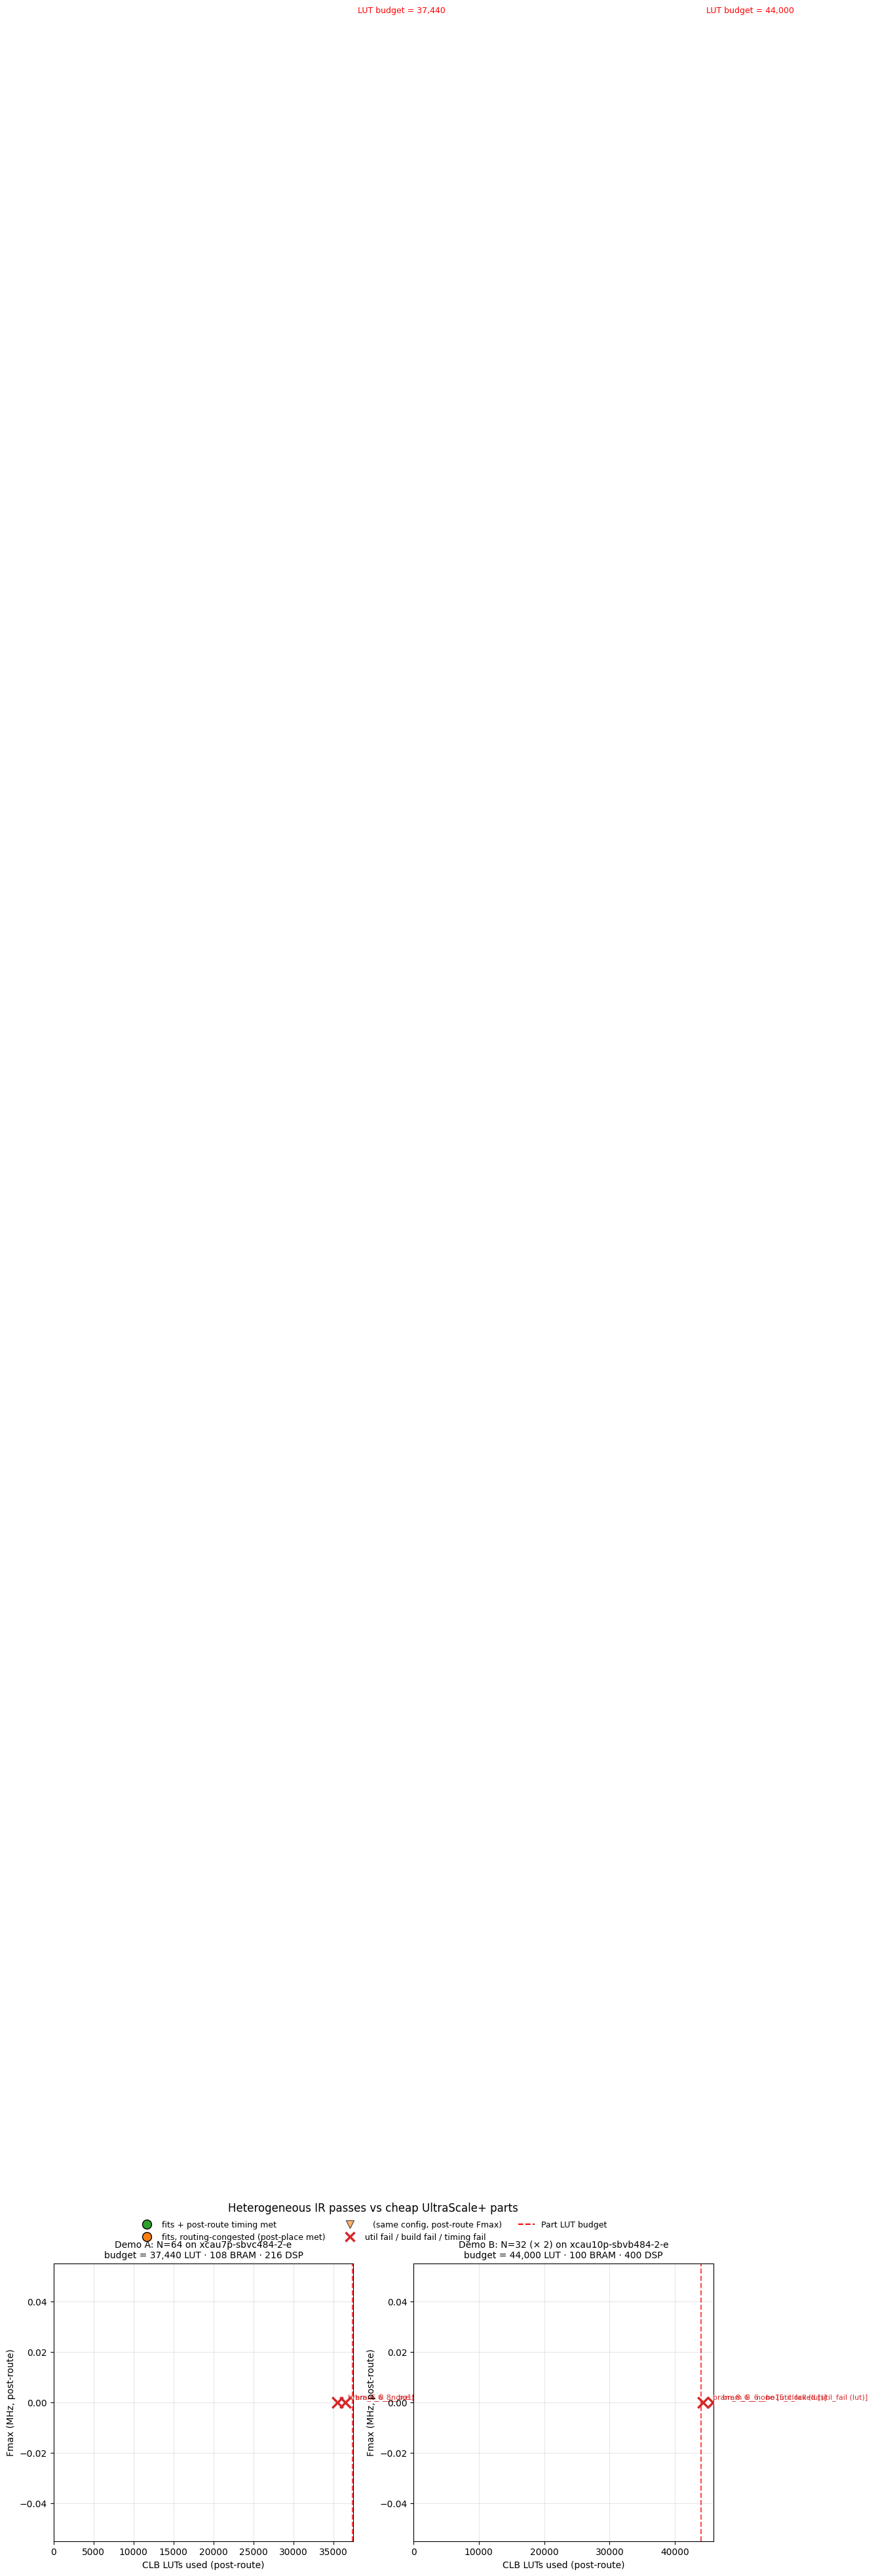

Saved /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/masters_results_5/part_fit_overview.png


In [12]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, (demo_id, demo_part, budget) in zip(axes, [
    ('A', DEMO_A_PART, DEMO_A_BUDGET),
    ('B', DEMO_B_PART, DEMO_B_BUDGET),
]):
    sub = df[df['demo'] == demo_id]
    ax.axvline(budget['lut'], color='red', linestyle='--', alpha=0.7, lw=1.5)
    ax.text(budget['lut'], ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 50,
            f'  LUT budget = {budget["lut"]:,}', color='red',
            verticalalignment='top', fontsize=9)
    for _, r in sub.iterrows():
        x = r['lut_used']
        y = r['fmax_mhz']        # post-place Fmax
        status = r['status']
        fits_clean       = status == 'fits'
        fits_congested   = status == 'fits (routing-congested)'
        if pd.notna(x) and pd.notna(y) and (fits_clean or fits_congested):
            color = 'tab:green' if fits_clean else 'tab:orange'
            ax.scatter([x], [y], s=140, color=color, marker='o', edgecolor='k', zorder=3)
            tag = f'  {r["label"]}'
            ax.annotate(tag, (x, y), textcoords='offset points', xytext=(6, 4), fontsize=8)
            if fits_congested and pd.notna(r['post_route_fmax_mhz']):
                ax.scatter([x], [r['post_route_fmax_mhz']], s=80, color='tab:orange',
                           marker='v', edgecolor='k', alpha=0.6, zorder=2)
                ax.annotate(f'  (post-route)', (x, r['post_route_fmax_mhz']),
                            textcoords='offset points', xytext=(6, -2), fontsize=7, color='tab:orange')
        elif pd.notna(x):
            color = 'tab:red'
            ax.scatter([x], [0], s=140, color=color, marker='x', linewidth=2.5, zorder=3)
            tag = f'  {r["label"]} [{status}]'
            ax.annotate(tag, (x, 0), textcoords='offset points', xytext=(6, 4), fontsize=8, color=color)

    instances = (df[df['demo'] == demo_id]['n_instances'].iloc[0]
                 if not df[df['demo'] == demo_id].empty else 1)
    suffix = f' (× {instances})' if instances > 1 else ''
    ax.set_title(f'Demo {demo_id}: N={32 if demo_id == "B" else 64}{suffix} on {demo_part}\n'
                 f'budget = {budget["lut"]:,} LUT · {budget["bram_tiles"]} BRAM · {budget["dsp"]} DSP', fontsize=10)
    ax.set_xlabel('CLB LUTs used (post-route)')
    ax.set_ylabel('Fmax (MHz, post-route)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)

handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tab:green',
           markeredgecolor='k', markersize=10, label='fits + post-route timing met'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tab:orange',
           markeredgecolor='k', markersize=10, label='fits, routing-congested (post-place met)'),
    Line2D([0],[0], marker='v', color='w', markerfacecolor='tab:orange',
           markeredgecolor='k', markersize=8, alpha=0.6, label='   (same config, post-route Fmax)'),
    Line2D([0],[0], marker='x', color='tab:red', linestyle='None',
           markersize=10, markeredgewidth=2.5, label='util fail / build fail / timing fail'),
    Line2D([0],[0], linestyle='--', color='red', label='Part LUT budget'),
]
fig.legend(handles=handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=9)

fig.suptitle('Heterogeneous IR passes vs cheap UltraScale+ parts', fontsize=12, y=1.05)
plt.tight_layout()
plt.savefig(NB_DIR / 'part_fit_overview.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved {NB_DIR / "part_fit_overview.png"}')


Power reports -> energy per inference, cross-part comparison.

In [ ]:
import re as _re_pow
import numpy as _np_pow

def _parse_power(rpt_path):
    """Return (total_W, dynamic_W, static_W). NaN if unreadable."""
    if not rpt_path.exists(): return float('nan'), float('nan'), float('nan')
    text = rpt_path.read_text()
    def _f(pat):
        m = _re_pow.search(pat, text)
        return float(m.group(1)) if m else float('nan')
    return (_f(r'Total On-Chip Power \(W\)\s*\|\s*([\d.]+)'),
            _f(r'Dynamic \(W\)\s*\|\s*([\d.]+)'),
            _f(r'Device Static \(W\)\s*\|\s*([\d.]+)'))

from pathlib import Path as _Path
import pandas as _pd

def _power_row_from_record(r):
    rpt = r['prj_dir'] / 'output_jsc' / 'reports' / 'jsc_post_route_power.rpt'
    total, dyn, static = _parse_power(rpt)
    drow = df[(df['demo'] == r['demo']) & (df['label'] == r['label'])].iloc[0]
    # Use post-route Fmax if we have it; else fall back to post-place
    fmax_pr = drow.get('post_route_fmax_mhz', _np_pow.nan)
    fmax = fmax_pr if not _np_pow.isnan(fmax_pr) else drow['fmax_mhz']
    n_inst = r['n_instances']
    if fmax > 0 and not _np_pow.isnan(total):
        period_ns = 1000.0 / fmax
        e_nJ = total * period_ns / n_inst   # W * ns = nJ
        inf_per_s = fmax * 1e6 * n_inst
    else:
        period_ns = e_nJ = inf_per_s = _np_pow.nan
    return dict(
        demo=r['demo'], label=r['label'], part=r['part_name'],
        n_inst=n_inst, model_n=r['model_n'],
        total_W=total, dyn_W=dyn, static_W=static,
        fmax_MHz=fmax, m_inf_per_s=inf_per_s/1e6 if inf_per_s == inf_per_s else _np_pow.nan,
        nJ_per_inf=e_nJ,
        status=drow['status'],
    )

rows = [_power_row_from_record(r) for r in records_A + records_B]

# Add cross-experiment reference: paper_baseline N=64 on xczu7ev (masters_results_3)
ref_dirs = [
    ('masters_results_3', 'paper_baseline', 64, 1, 'xczu7ev (ref, $1k)', 2.5,
     HGQ_JSC150 / 'masters_results_3' / 'paper_baseline' / 'epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534'),
    ('masters_results_3', 'bram_7_5__bo15_clocked', 64, 1, 'xczu7ev (ref, $1k)', 2.5,
     HGQ_JSC150 / 'masters_results_3' / 'bram_7_5__bo15_clocked' / 'epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534'),
    ('n32_validation', 'none', 32, 1, 'xczu7ev (ref, $1k)', 5.0,
     HGQ_JSC150 / 'n32_validation' / 'none' / 'epoch=5406-val_acc=0.805-ebops=27012-val_loss=0.570'),
]
for exp, label, model_n, n_inst, part_hint, period_ns_ref, prj_dir in ref_dirs:
    rpt = prj_dir / 'output_jsc' / 'reports' / 'jsc_post_route_power.rpt'
    tim = prj_dir / 'output_jsc' / 'reports' / 'jsc_post_route_timing.rpt'
    total, dyn, static = _parse_power(rpt)
    wns_match = _re_pow.search(r'WNS\(ns\)[^\n]*\n[^\n]*\n\s*([-\d.]+)', tim.read_text()) if tim.exists() else None
    wns = float(wns_match.group(1)) if wns_match else _np_pow.nan
    fmax = 1000.0 / (period_ns_ref - wns) if not _np_pow.isnan(wns) and (period_ns_ref - wns) > 0 else _np_pow.nan
    e_nJ = total * (1000.0 / fmax) / n_inst if fmax > 0 and not _np_pow.isnan(total) else _np_pow.nan
    rows.append(dict(
        demo='ref-' + exp, label=label, part=part_hint, n_inst=n_inst, model_n=model_n,
        total_W=total, dyn_W=dyn, static_W=static,
        fmax_MHz=fmax, m_inf_per_s=fmax*n_inst if fmax == fmax else _np_pow.nan,
        nJ_per_inf=e_nJ, status='reference',
    ))

df_energy = _pd.DataFrame(rows)
df_energy.to_csv(NB_DIR / 'part_fit_energy.csv', index=False)

print('Power + throughput + energy per inference:')
print('(nJ_per_inf = nJ per single jet; for Demo B that means per N=32 jet, '
      'not per dual-pair)\n')
fmt = {
    'total_W':     '{:.3f}'.format,
    'dyn_W':       '{:.3f}'.format,
    'static_W':    '{:.3f}'.format,
    'fmax_MHz':    '{:.1f}'.format,
    'm_inf_per_s': '{:.1f}'.format,
    'nJ_per_inf':  '{:.3f}'.format,
}
print(df_energy[['demo','label','part','n_inst','model_n','total_W','dyn_W',
                 'fmax_MHz','m_inf_per_s','nJ_per_inf','status']]
      .to_string(index=False, formatters=fmt, na_rep='-'))

# Headline summary
print('\n=== HEADLINE: per-jet energy by deployment scenario ===')
def _pick(demo, label):
    sub = df_energy[(df_energy['demo']==demo) & (df_energy['label']==label)]
    return sub.iloc[0] if len(sub) else None

scenarios = [
    ('paper N=64 on xczu7ev ($1k)',          _pick('ref-masters_results_3', 'paper_baseline')),
    ('paper N=64 on xcau7p   ($60)',         _pick('A', 'paper_baseline')),
    ('bram_6_8 N=64 on xcau7p ($60)',        _pick('A', 'bram_6_8__none')),
    ('paper N=32 on xczu7ev ($1k)',          _pick('ref-n32_validation', 'none')),
    ('bram_8_6 N=32 ×2 on xcau10p ($75)',    _pick('B', 'bram_8_6__none')),
    ('bram_8_6+DSP N=32 ×2 on xcau10p ($75)', _pick('B', 'bram_8_6__bo15_clocked')),
]
for tag, r in scenarios:
    if r is None: continue
    print(f'  {tag:<45s}  {r["total_W"]:.2f} W  {r["m_inf_per_s"]:>7.1f} M-jets/s  '
          f'{r["nJ_per_inf"]:.2f} nJ/jet')
